# Advanced Performance

`MajoranaPropagation.jl` builds on `PauliPropagation.jl` and, like it, is designed to be modular, extensible, and easy to use at a high level. At the same time, we want to enable state-of-the-art Majorana propagation performance. This is a notebook explaining how to squeeze the most out of this library.

In [1]:
using MajoranaPropagation
using MajoranaPropagation.Performance
using Base.Threads
using Printf
using Plots

println("Threads.nthreads() = $(nthreads())")

Threads.nthreads() = 4


## A $4\times4$ Fermi-Hubbard circuit

We consider the Trotterized dynamics of the spinful Fermi-Hubbard model on a $4 \times 4$ lattice,
$$\hat{H}=-t \sum_{\langle i,j\rangle, \sigma=\{\uparrow, \downarrow\}}\left(\hat{c}_{i, \sigma}^{\dagger} \hat{c}_{j, \sigma}+\hat{c}_{j, \sigma}^{\dagger} \hat{c}_{i, \sigma}\right)+U \sum_i \hat{n}_{i \uparrow} \hat{n}_{i \downarrow}.$$
One first-order Trotter layer consists of a `:hopup` and a `:hopdn` rotation on every bond and a `:nupndn` rotation on every site. The observable is the double occupancy $\hat n_{i\uparrow} \hat n_{i\downarrow}$ of a site in the middle of the lattice, evaluated in the checkerboard Fock state $|\uparrow\downarrow\uparrow\downarrow\cdots\rangle$. Besides the coefficient truncation `min_abs_coeff`, we drop Majorana strings with more than `max_unpaired` unpaired Majorana operators, i.e. modes on which only one of $\gamma_i$, $\gamma_i'$ is present.

In [2]:
N_x = 4
N_y = 4
N_sites = N_x * N_y

t = 1.0
U = 2.0
dt = 0.07

topology = rectangletopology(N_x, N_y)

layer = FermionicRotation[]
thetas = Float64[]
for (i, j) in topology
    push!(layer, FermionicRotation(:hopup, [i, j]))
    push!(thetas, -t * dt)
    push!(layer, FermionicRotation(:hopdn, [i, j]))
    push!(thetas, -t * dt)
end
for i in 1:N_sites
    push!(layer, FermionicRotation(:nupndn, i))
    push!(thetas, U * dt)
end

site = (N_y ÷ 2 - 1) * N_x + N_x ÷ 2 + 1
obs = MajoranaSum(N_sites, :nupndn, site)
fock_state = FockState(N_sites, :checkerboard, true; nx=N_x)

min_abs_coeff = 1e-5
max_unpaired = 6

nlayers = 10;

## Switching to `VectorMajoranaSum`

Most of our examples use the `MajoranaSum` type, which stores Majorana strings and their coefficients in a `Dict`. It is flexible and generally a robust choice. Our first performance suggestion is to switch to `VectorMajoranaSum`, which stores Majorana strings and their coefficients in two `Vector`s. A rotation then only appends the new strings, and they are merged back in by a sorting pass that exploits how a rotation acts on a sorted list of strings.

Let us run all 10 layers with either type.

In [3]:
circuit = repeat(layer, nlayers)
circuit_thetas = repeat(thetas, nlayers)

# one layer up front so that the timings below are not dominated by compilation
propagate(layer, obs, thetas; min_abs_coeff, max_unpaired)
propagate(layer, VectorMajoranaSum(obs), thetas; min_abs_coeff, max_unpaired)

t_dict = @elapsed dict_msum = propagate(circuit, obs, circuit_thetas; min_abs_coeff, max_unpaired)
t_vec = @elapsed vec_msum = propagate(circuit, VectorMajoranaSum(obs), circuit_thetas; min_abs_coeff, max_unpaired)

@printf("MajoranaSum:        %5.2f s   (%d Majorana strings)\n", t_dict, length(dict_msum))
@printf("VectorMajoranaSum:  %5.2f s   (%d Majorana strings)\n", t_vec, length(vec_msum))

MajoranaSum:         9.25 s   (1416840 Majorana strings)
VectorMajoranaSum:   1.51 s   (1416840 Majorana strings)


Both give the same expectation value $\langle \hat n_{i\uparrow} \hat n_{i\downarrow}\rangle$.

In [4]:
overlapwithfock(dict_msum, fock_state), overlapwithfock(vec_msum, fock_state)

(0.21526921892121417, 0.2152692189212134)

## Threading

Both `VectorMajoranaSum` runs above were multi-threaded, which is the default. `thread=false` forces a single-threaded propagation. Threading pays off once the Majorana sum is large enough that the work per task outweighs the cost of spawning tasks. It is also the wrong choice if you already parallelize at a higher level, because the nested tasks would only compete for the same cores.

In [5]:
t_serial = @elapsed propagate(circuit, VectorMajoranaSum(obs), circuit_thetas; min_abs_coeff, max_unpaired, thread=false)

@printf("thread=false:  %5.2f s\n", t_serial)
@printf("thread=true:   %5.2f s\n", t_vec)

thread=false:   2.80 s
thread=true:    1.51 s


## Propagating in-place with `PropagationCache`

`propagate` returns a fresh Majorana sum on every call. A Trotterized time evolution applies the same layer over and over, and usually wants an expectation value after every step, so we would rather advance one Majorana sum in place. That is what `PropagationCache` and `propagate!` are for.

The cache holds a main and an auxiliary Majorana sum, plus a few scratch arrays. Every `propagate!` call writes into the auxiliary sum and then swaps the two, so no new memory is needed in between. `resize!(prop_cache, N)` grows all of these arrays once up front, with `N` a generous estimate of the final number of Majorana strings, so that they do not have to grow during the run.

Expectation values can be read straight off the cache with `overlapwithfock(prop_cache, fock_state)`, without extracting a Majorana sum.

In [6]:
prop_cache = PropagationCache(VectorMajoranaSum(obs))
resize!(prop_cache, 2_000_000)

expectations = Float64[]
nterms = Int[]

t_cache = @elapsed for l in 1:nlayers
    propagate!(layer, prop_cache, thetas; min_abs_coeff, max_unpaired)
    push!(expectations, overlapwithfock(prop_cache, fock_state))
    push!(nterms, length(prop_cache))
end

@printf("propagate! into a cache:  %5.2f s   (%d Majorana strings)\n", t_cache, length(prop_cache))

propagate! into a cache:   1.46 s   (1416840 Majorana strings)


The whole time series comes out of that single sweep.

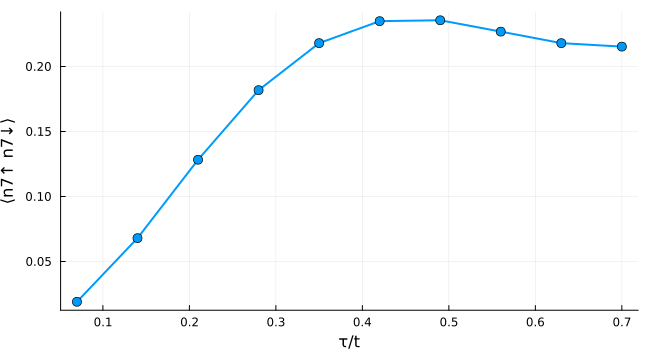

In [7]:
plot(dt * (1:nlayers), expectations, xlabel="τ/t", ylabel="⟨n$(site)↑ n$(site)↓⟩", legend=false,
    linewidth=2, marker=:circle, markersize=5, size=(650, 350))

## Fused truncations in `MajoranaPropagation.Performance`

By default, every gate is applied in three steps: the rotation appends the new Majorana strings, the merge sorts them in, and a separate pass then truncates the sum. `MajoranaPropagation.Performance` is an opt-in module with fused versions of `propagate` and `propagate!` that fold the truncations into the other two steps: a new string that would exceed `max_weight` or `max_unpaired` is dropped as it is created and never stored, and the remaining truncations are applied by the merge itself. The results are identical to the default path. Passing `fused=false` falls back to the default behavior.

In [8]:
fused_cache = PropagationCache(VectorMajoranaSum(obs))
resize!(fused_cache, 2_000_000)

# one layer on a throwaway cache to compile the fused kernels
Performance.propagate!(layer, PropagationCache(VectorMajoranaSum(obs)), thetas; min_abs_coeff, max_unpaired)

t_fused = @elapsed for l in 1:nlayers
    Performance.propagate!(layer, fused_cache, thetas; min_abs_coeff, max_unpaired)
end

@printf("Performance.propagate!:  %5.2f s   (%d Majorana strings)\n", t_fused, length(fused_cache))
@printf("⟨n↑ n↓⟩ = %.14f  vs  %.14f\n", overlapwithfock(fused_cache, fock_state), expectations[end])

Performance.propagate!:   1.34 s   (1416840 Majorana strings)
⟨n↑ n↓⟩ = 0.21526921892121  vs  0.21526921892121


The same works for the dictionary-based `MajoranaSum`, where the fused kernel updates the `Dict` in place instead of building a second one and merging it.

In [9]:
# again a first call to compile
Performance.propagate(layer, obs, thetas; min_abs_coeff, max_unpaired)

t_fused_dict = @elapsed fused_dict_msum = Performance.propagate(circuit, obs, circuit_thetas; min_abs_coeff, max_unpaired)

@printf("Performance.propagate on a MajoranaSum:  %5.2f s   (%d Majorana strings)\n", t_fused_dict, length(fused_dict_msum))
@printf("⟨n↑ n↓⟩ = %.14f  vs  %.14f\n", overlapwithfock(fused_dict_msum, fock_state), overlapwithfock(dict_msum, fock_state))

Performance.propagate on a MajoranaSum:   5.82 s   (1416840 Majorana strings)
⟨n↑ n↓⟩ = 0.21526921892121  vs  0.21526921892121


## Not all gates cost the same

A Majorana rotation only branches the Majorana strings that anticommute with its generator, and leaves the rest untouched. What a gate costs therefore depends on where it sits. Take the Majorana sum after all 10 layers and apply a single hopping gate to it, once on a bond at a corner of the lattice and once on a bond next to the observable. In the middle, a good fraction of the sum branches; at the corner, the few branches that appear fall below `min_abs_coeff` right away.

In [10]:
snapshot = VectorMajoranaSum(fused_cache)
n = length(snapshot)
theta = -t * dt

corner_bond = topology[1]
middle_bond = topology[findfirst(bond -> site in bond, topology)]
corner_gate = FermionicRotation(:hopup, corner_bond)
middle_gate = FermionicRotation(:hopup, middle_bond)

corner_cache = PropagationCache(deepcopy(snapshot))
resize!(corner_cache, 2n)
middle_cache = PropagationCache(deepcopy(snapshot))
resize!(middle_cache, 2n)

# one gate on a throwaway cache to compile, again
Performance.propagate!(corner_gate, PropagationCache(VectorMajoranaSum(obs)), theta; min_abs_coeff, max_unpaired)

t_corner = @elapsed Performance.propagate!(corner_gate, corner_cache, theta; min_abs_coeff, max_unpaired)
t_middle = @elapsed Performance.propagate!(middle_gate, middle_cache, theta; min_abs_coeff, max_unpaired)

@printf("hopping on bond %s:    %5.0f M strings/s   (%d -> %d strings)\n", corner_bond, n / t_corner / 1e6, n, length(corner_cache))
@printf("hopping on bond %s:  %5.0f M strings/s   (%d -> %d strings)\n", middle_bond, n / t_middle / 1e6, n, length(middle_cache))

hopping on bond (1, 5):      204 M strings/s   (1416840 -> 1415258 strings)
hopping on bond (3, 7):    106 M strings/s   (1416840 -> 1420045 strings)


## Before and after

Let us count how many Majorana strings we work through per second while we apply our gates. Every fermionic gate decomposes into several Majorana rotations, and each of those walks the whole sum once.

In [11]:
nrotations = sum(length(MajoranaPropagation.getmajoranarotations(gate, N_sites)[1]) for gate in layer)
napplied = nrotations * sum([1; nterms[1:end-1]])

labels = ["MajoranaSum", "VectorMajoranaSum\nserial", "VectorMajoranaSum\nthreaded", "+ propagate!\ninto a cache", "+ Performance\nfused"]
times = [t_dict, t_serial, t_vec, t_cache, t_fused]
rates = napplied ./ times ./ 1e6

@printf("%d rotation applications on Majorana strings in total\n\n", napplied)
for (l, t, r) in zip(labels, times, rates)
    @printf("%-28s %6.2f s   %6.1f M strings/s\n", replace(l, "\n" => " "), t, r)
end

296266752 rotation applications on Majorana strings in total

MajoranaSum                    9.25 s     32.0 M strings/s


VectorMajoranaSum serial       2.80 s    105.8 M strings/s
VectorMajoranaSum threaded     1.51 s    196.1 M strings/s
+ propagate! into a cache      1.46 s    202.9 M strings/s
+ Performance fused            1.34 s    220.7 M strings/s


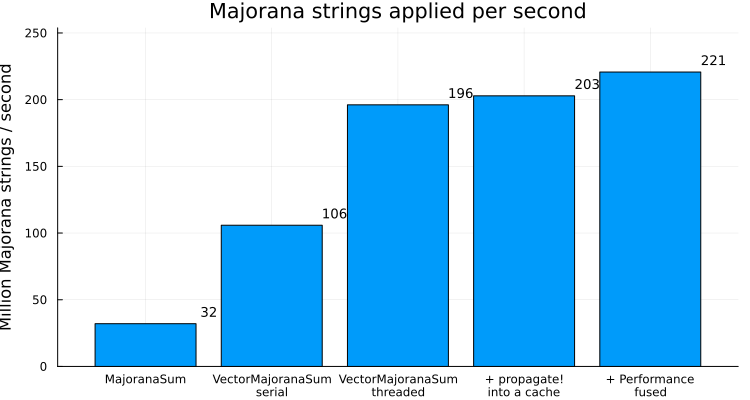

In [12]:
p = bar(labels, rates, legend=false, ylabel="Million Majorana strings / second", size=(750, 400),
    ylims=(0, 1.15 * maximum(rates)), title="Majorana strings applied per second")
annotate!(p, 1:length(rates), rates .+ 0.04 * maximum(rates), [text(@sprintf("%.0f", r), 9) for r in rates])
p

## Summary

Switch to `VectorMajoranaSum` once your Majorana sums reach hundreds of thousands of strings, and let it thread unless you are already parallelizing somewhere above. For layered evolution, keep a `PropagationCache`, `resize!` it up front, advance it with `propagate!`, and evaluate the observables off the cache after every layer. If you need to squeeze out all the performance this library has to offer, `MajoranaPropagation.Performance` fuses the truncations into the gate application for exactly that, on either backend and with identical results.